# 03 - Modelagem Preditiva

## Objetivo

Construir um modelo para estimar a probabilidade de uma oferta ser concluída por um cliente.

A base final está na granularidade:

```text
1 linha = 1 envio de oferta para 1 cliente
```

A modelagem usa apenas informações disponíveis **antes do recebimento da oferta**, além das características da própria oferta.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
import os

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("offer_personalization_data_processing")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
spark.version

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/19 02:48:21 WARN Utils: Your hostname, jorel.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.7 instead (on interface en0)
26/05/19 02:48:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 02:48:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/19 02:48:22 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/19 02:48:22 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


'4.0.2'

## Leitura da base final

In [3]:
import os

candidate_paths = [
    "../data/processed/customer_offer_final.parquet",
    "../data/processed/customer_offer_transactions.parquet"
]

data_path = next(
    path for path in candidate_paths
    if os.path.exists(path)
)

customer_offer_final = spark.read.parquet(data_path)

print(f"Loaded dataset from: {data_path}")
customer_offer_final.printSchema()

Loaded dataset from: ../data/processed/customer_offer_transactions.parquet
root
 |-- account_id: string (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- offer_received_time: double (nullable = true)
 |-- offer_viewed_time: double (nullable = true)
 |-- offer_completed_time: double (nullable = true)
 |-- offer_received: integer (nullable = true)
 |-- offer_viewed: integer (nullable = true)
 |-- offer_completed: integer (nullable = true)
 |-- time_to_view: double (nullable = true)
 |-- time_to_complete: double (nullable = true)
 |-- previous_offer_time_to_complete: double (nullable = true)
 |-- transactions_during_offer: long (nullable = true)
 |-- amount_during_offer: double (nullable = true)
 |-- reward: double (nullable = true)
 |-- discount_value: double (nullable = true)
 |-- min_value: double (nullable = true)
 |-- duration: double (nullable = true)
 |-- offer_type: string (nullable = true)
 |-- email: integer (nullable = true)
 |-- mobile: integer (nullable = true)
 

In [4]:
customer_offer_final.show(5, truncate=False)

+--------------------------------+--------------------------------+-------------------+-----------------+--------------------+--------------+------------+---------------+------------+----------------+-------------------------------+-------------------------+-------------------+------+--------------+---------+--------+----------+-----+------+------+---+---+------+-----------------+-------------+----------------+-------------------------+-------------------+----------------------+-----------------------+----------------------------+--------------------------------+-----------------------+----------------------+
|account_id                      |offer_id                        |offer_received_time|offer_viewed_time|offer_completed_time|offer_received|offer_viewed|offer_completed|time_to_view|time_to_complete|previous_offer_time_to_complete|transactions_during_offer|amount_during_offer|reward|discount_value|min_value|duration|offer_type|email|mobile|social|web|age|gender|credit_card_limit|

## Definição da base de modelagem

Como ofertas informacionais não possuem evento de conclusão equivalente às ofertas promocionais, a modelagem principal será feita apenas com:

- `bogo`
- `discount`

O objetivo é estimar:

```text
P(offer_completed = 1 | cliente, oferta, histórico prévio)
```

In [5]:
model_sdf = (
    customer_offer_final
    .filter(col("offer_type").isin(["bogo", "discount"]))
)

print(f"Linhas na base promocional: {model_sdf.count():,}")
print(f"Clientes únicos: {model_sdf.select('account_id').distinct().count():,}")

Linhas na base promocional: 61,042
Clientes únicos: 16,928


## Seleção de variáveis

Variáveis com leakage temporal ou identificadores foram removidas:

- `account_id`
- `offer_id`
- `offer_received_time`
- `offer_viewed_time`
- `offer_completed_time`
- `time_to_view`
- `time_to_complete`
- `offer_viewed`
- `reward`
- `transactions_during_offer`
- `amount_during_offer`

Essas variáveis utilizam informações posteriores ao envio da oferta ou identificadores sem poder preditivo generalizável.

In [6]:
model_df = model_sdf.select(
    "account_id",
    # target
    "offer_completed",

    # características da oferta
    "discount_value",
    "min_value",
    "duration",
    "offer_type",
    "email",
    "mobile",
    "social",
    "web",

    # perfil do cliente
    "age",
    "gender",
    "credit_card_limit",
    "account_age_days",

    # histórico pré-oferta
    "transactions_before_offer",
    "amount_before_offer",
    "offers_received_before",
    "offers_completed_before",
    "bogo_offers_completed_before",
    "discount_offers_completed_before",
    "avg_ticket_before_offer",
    "completion_rate_before",
    "previous_offer_time_to_complete"
)

In [7]:
pdf = model_df.toPandas()
pdf.head()

,account_id,offer_completed,discount_value,min_value,duration,offer_type,email,mobile,social,web,age,gender,credit_card_limit,account_age_days,transactions_before_offer,amount_before_offer,offers_received_before,offers_completed_before,bogo_offers_completed_before,discount_offers_completed_before,avg_ticket_before_offer,completion_rate_before,previous_offer_time_to_complete
0,d80ce36710b34270bb543898db2f1882,1,10.0,10.0,7.0,bogo,1,1,1,0,37.0,M,85000.0,209,2,49.13,1,1,0,1,24.565000,1.000000,1.5
1,d80ce36710b34270bb543898db2f1882,0,5.0,5.0,7.0,bogo,1,1,0,1,37.0,M,85000.0,209,3,65.62,2,2,1,1,21.873333,1.000000,0.5
2,d80ce36710b34270bb543898db2f1882,1,2.0,10.0,10.0,discount,1,1,1,1,37.0,M,85000.0,209,3,65.62,3,2,1,1,21.873333,0.666667,0.0
3,d80f9e3f974448ec902c42818097ebf3,1,2.0,10.0,10.0,discount,1,1,1,1,47.0,F,62000.0,339,0,0.00,0,0,0,0,0.000000,0.000000,0.0
4,d80f9e3f974448ec902c42818097ebf3,1,2.0,10.0,7.0,discount,1,1,0,1,47.0,F,62000.0,339,2,26.13,1,1,0,1,13.065000,1.000000,0.5


## Tratamento de nulos

Para `credit_card_limit`, será criada uma flag de ausência antes da imputação.

In [8]:
pdf["credit_card_limit_missing"] = pdf["credit_card_limit"].isna().astype(int)

In [9]:
missing_df = (
    pdf.isna()
    .sum()
    .reset_index()
)

missing_df.columns = ["feature", "missing_count"]

missing_df["missing_pct"] = (
    missing_df["missing_count"] / len(pdf)
) * 100

missing_df.sort_values(
    "missing_pct",
    ascending=False
)

,feature,missing_count,missing_pct
10,age,7900,12.941909
12,credit_card_limit,7841,12.845254
13,account_age_days,0,0.000000
22,previous_offer_time_to_complete,0,0.000000
21,completion_rate_before,0,0.000000
20,avg_ticket_before_offer,0,0.000000
19,discount_offers_completed_before,0,0.000000
18,bogo_offers_completed_before,0,0.000000
17,offers_completed_before,0,0.000000
16,offers_received_before,0,0.000000


As variáveis numéricas com valores ausentes foram tratadas utilizando imputação pela mediana dentro do pipeline de modelagem. Para `credit_card_limit`, também foi criada uma flag indicando ausência da informação.

## Separação entre features e target

In [10]:
target = "offer_completed"

X = pdf.drop(columns=[target])
y = pdf[target].astype(int)

y.value_counts(normalize=True)

offer_completed
1    0.550949
0    0.449051
Name: proportion, dtype: float64

## Separação treino e teste por cliente

Como existem múltiplas linhas para um mesmo cliente, a separação entre treino e teste precisa respeitar o agrupamento por `account_id`.

Isso evita que o mesmo cliente apareça nos dois conjuntos e reduz vazamento de informação entre treino e teste.

In [11]:
groups = pdf["account_id"]

In [12]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [13]:
X_train = X_train.drop(columns=["account_id"])
X_test = X_test.drop(columns=["account_id"])
X = X.drop(columns=["account_id"])

In [14]:
categorical_features = [
    "gender",
    "offer_type"
]

numeric_features = [
    col_name for col_name in X.columns
    if col_name not in categorical_features
]

## Pipeline de pré-processamento

In [15]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Função de avaliação

In [16]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "avg_precision": average_precision_score(y_test, y_proba)
    }

    print(model_name)
    print(classification_report(y_test, y_pred))

    return metrics, y_pred, y_proba

## Modelos

In [17]:
models = {
    "Baseline": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", DummyClassifier(strategy="most_frequent"))
        ]
    ),

    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", GradientBoostingClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            ))
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "LightGBM": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                random_state=42,
                verbose=-1,
                n_jobs=-1
            ))
        ]
    )
}

## Comparação dos modelos

In [18]:
model_results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    trained_models[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

    model_results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "avg_precision": average_precision_score(y_test, y_proba)
    })

model_results = (
    pd.DataFrame(model_results)
    .sort_values("roc_auc", ascending=False)
)

model_results

/Users/dieb/Documents/case_ifood/offer-recommendation/venv_pyspark/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/dieb/Documents/case_ifood/offer-recommendation/venv_pyspark/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,roc_auc,avg_precision
5,LightGBM,0.878520,0.893741
4,XGBoost,0.877954,0.893138
3,Gradient Boosting,0.874900,0.889951
2,Random Forest,0.871516,0.884355
1,Logistic Regression,0.827746,0.833909
0,Baseline,0.500000,0.553724


In [19]:
best_model_name = model_results.iloc[0]["model"]

final_model = trained_models[best_model_name]["model"]
final_y_pred = trained_models[best_model_name]["y_pred"]
final_y_proba = trained_models[best_model_name]["y_proba"]

print(f"Best model: {best_model_name}")

Best model: LightGBM


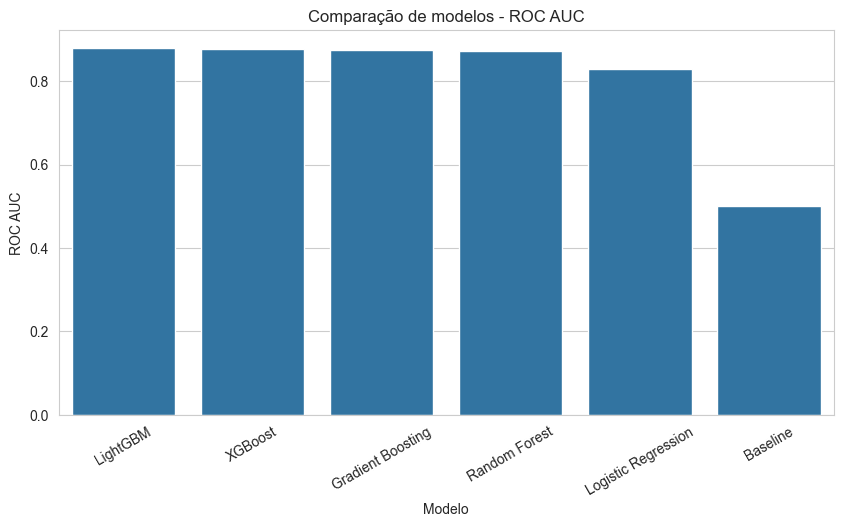

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_results,
    x="model",
    y="roc_auc"
)

plt.title("Comparação de modelos - ROC AUC")
plt.ylabel("ROC AUC")
plt.xlabel("Modelo")
plt.xticks(rotation=30)

plt.show()

## Curvas ROC e Precision-Recall

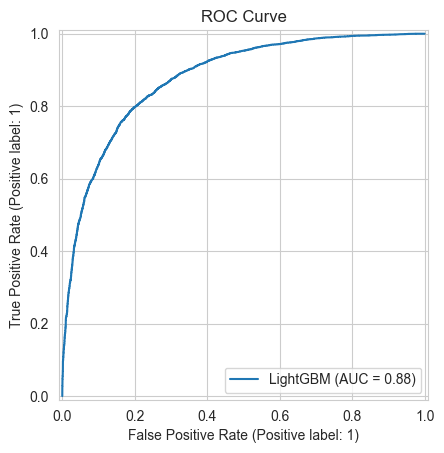

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    final_y_proba,
    name=best_model_name
)

plt.title("ROC Curve")
plt.show()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

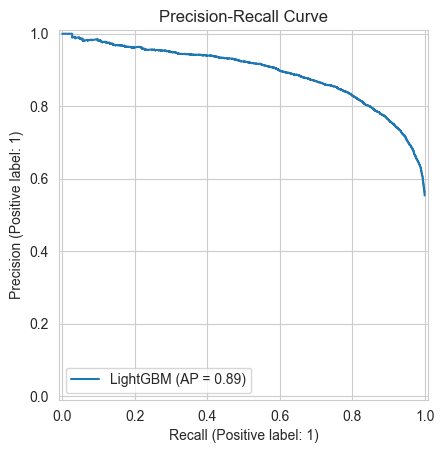

In [ ]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    final_y_proba,
    name=best_model_name
)

plt.title("Precision-Recall Curve")
plt.show()

plt.savefig(
    "../images/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

## Matriz de confusão do melhor modelo

A matriz abaixo mostra os acertos e erros do modelo selecionado automaticamente pelo maior ROC AUC.

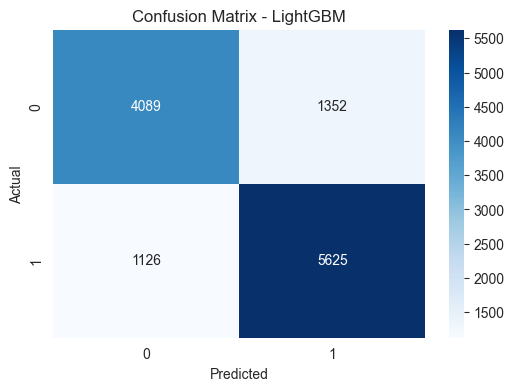

<Figure size 640x480 with 0 Axes>

In [42]:
cm = confusion_matrix(y_test, final_y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

## Avaliação do modelo final

O melhor modelo foi selecionado automaticamente a partir do maior ROC AUC no conjunto de teste.

A avaliação considera:

- **ROC AUC**: capacidade geral de separação entre ofertas convertidas e não convertidas;
- **Average Precision**: qualidade do ranking em termos de precisão e recall;
- **Precision / Recall / F1-score**: interpretação dos erros de classificação.

Como a modelagem utiliza apenas informações disponíveis antes do recebimento da oferta e a separação treino/teste foi realizada por cliente, os resultados ficam mais próximos de um cenário real de produção.

## Métricas de erro

In [24]:
print(classification_report(y_test, final_y_pred))

              precision    recall  f1-score   support

           0       0.78      0.75      0.77      5441
           1       0.81      0.83      0.82      6751

    accuracy                           0.80     12192
   macro avg       0.80      0.79      0.79     12192
weighted avg       0.80      0.80      0.80     12192



**Interpretação das métricas de classificação**

O modelo final apresentou desempenho equilibrado entre precision e recall para ambas as classes.

Para a classe de conversão (`offer_completed = 1`):

- Precision: 0.81
- Recall: 0.83
- F1-score: 0.82

Os resultados indicam que:

- a maior parte das ofertas priorizadas pelo modelo realmente convertem;
- o modelo consegue capturar a maioria das conversões reais;
- há equilíbrio entre eficiência promocional e cobertura de clientes propensos.

**False Positives**
O modelo prevê conversão, mas o cliente não converte.

Possíveis impactos:
- desperdício promocional;
- aumento de custo de campanha;
- excesso de comunicação.

**False Negatives**
O modelo não prioriza um cliente que converteria a oferta.

Possíveis impactos:
- perda de receita potencial;
- oportunidades promocionais desperdiçadas.

O equilíbrio observado entre precision e recall sugere boa capacidade do modelo em apoiar estratégias de priorização de campanhas promocionais.

## Importância das variáveis

In [25]:
encoded_cat_features = (
    final_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

feature_names = numeric_features + list(encoded_cat_features)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.named_steps["classifier"].feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
9,account_age_days,1602
16,avg_ticket_before_offer,1053
8,credit_card_limit,1031
11,amount_before_offer,887
7,age,705
18,previous_offer_time_to_complete,649
10,transactions_before_offer,512
12,offers_received_before,460
0,discount_value,366
1,min_value,335


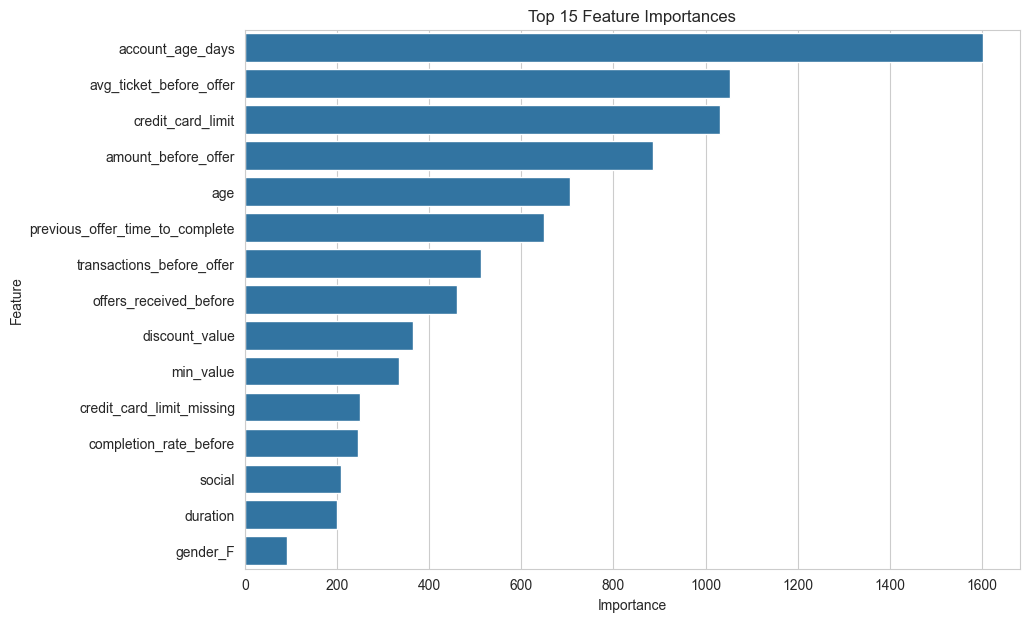

In [26]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Cross-validation e ajuste de hiperparâmetros

Abaixo está uma versão opcional e compacta de validação cruzada por cliente com `GroupKFold` e `RandomizedSearchCV`.

Ela foi mantida como opcional porque pode aumentar bastante o tempo de execução, mas demonstra como o tuning deveria ser feito sem misturar clientes entre treino e validação.

In [27]:
# from sklearn.model_selection import GroupKFold, RandomizedSearchCV
# from lightgbm import LGBMClassifier

# groups_cv = pdf["account_id"]
# X_cv = X.copy()
# y_cv = y.copy()

# gkf = GroupKFold(n_splits=3)

# lgbm_pipeline = Pipeline(
#     steps=[
#         ("preprocessor", preprocessor),
#         ("classifier", LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1))
#     ]
# )

# param_grid = {
#     "classifier__n_estimators": [100, 200],
#     "classifier__max_depth": [3, 5, -1],
#     "classifier__learning_rate": [0.03, 0.05, 0.1],
#     "classifier__num_leaves": [15, 31],
#     "classifier__min_child_samples": [20, 50]
# }

# random_search = RandomizedSearchCV(
#     estimator=lgbm_pipeline,
#     param_distributions=param_grid,
#     n_iter=5,
#     scoring="roc_auc",
#     cv=gkf,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(
#     X_cv,
#     y_cv,
#     groups=groups_cv
# )

# print("Best ROC AUC:", random_search.best_score_)
# print("Best Params:", random_search.best_params_)

# best_lgbm_model = random_search.best_estimator_

## SHAP values

In [29]:
# Amostra para acelerar o cálculo dos SHAP values
X_shap = X_test.sample(
    n=3000 if len(X_test) > 3000 else len(X_test),
    random_state=42
)

X_shap_transformed = final_model.named_steps["preprocessor"].transform(X_shap)
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

classifier = final_model.named_steps["classifier"]
explainer = shap.TreeExplainer(classifier)

shap_values = explainer.shap_values(X_shap_transformed)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

/Users/dieb/Documents/case_ifood/offer-recommendation/venv_pyspark/lib/python3.9/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


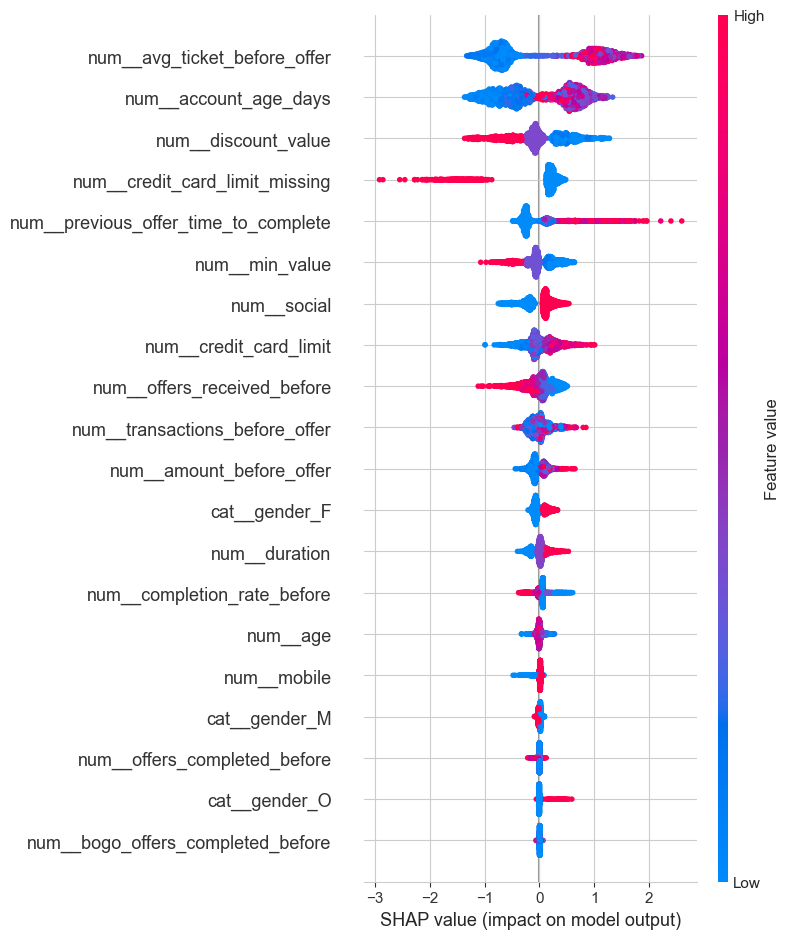

<Figure size 640x480 with 0 Axes>

In [43]:
shap.summary_plot(
    shap_values_plot,
    X_shap_transformed,
    feature_names=feature_names
)

plt.savefig(
    "../images/shap_values.png",
    dpi=300,
    bbox_inches="tight"
)

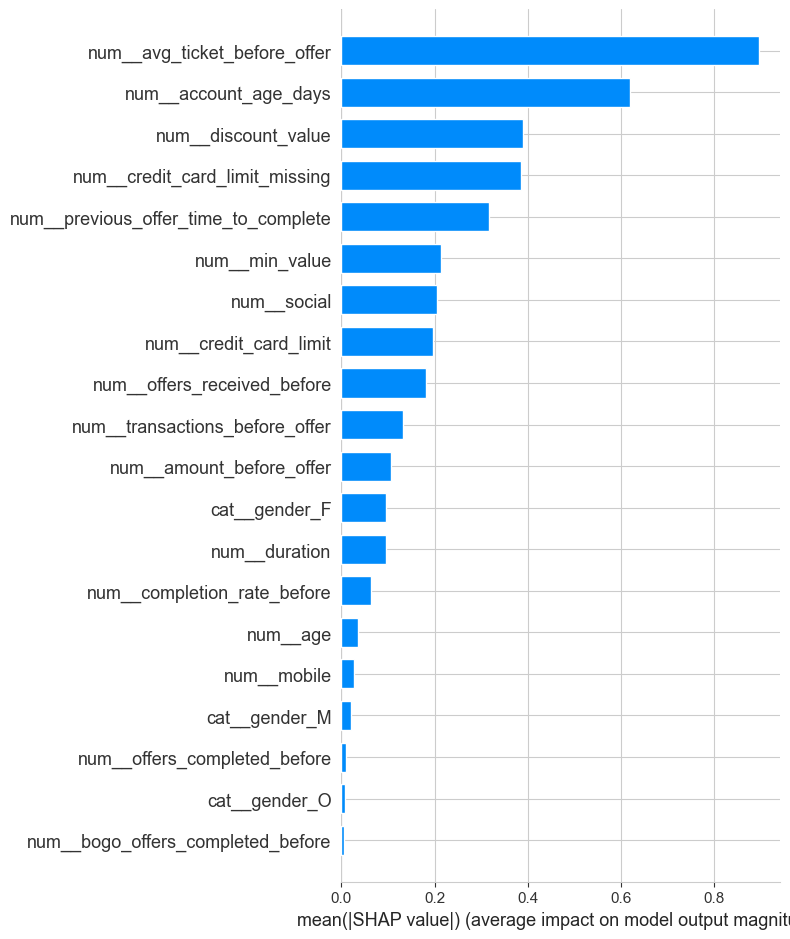

In [31]:
shap.summary_plot(
    shap_values_plot,
    X_shap_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

**Interpretabilidade com SHAP Values**

Os SHAP values foram utilizados para interpretar o impacto das variáveis nas previsões do modelo LightGBM.

Os resultados mostraram que:

- clientes com maior ticket médio histórico possuem maior propensão de conversão;
- clientes mais antigos tendem a responder melhor às campanhas;
- o tempo histórico para concluir ofertas anteriores apresentou forte relação com conversões futuras;
- canais sociais aparentam aumentar a probabilidade de conversão;
- a ausência de informação de limite de crédito também apresentou sinal relevante para o modelo.

Além disso, os gráficos indicam relações não lineares entre variáveis e probabilidade prevista, reforçando a escolha de modelos baseados em árvores de decisão.

As características das ofertas, como duração, valor mínimo e desconto, foram incluídas na modelagem por representarem informações disponíveis no momento do envio da campanha.

Essas variáveis permitem ao modelo aprender interações entre perfil do cliente e mecânica promocional, aproximando o problema de um cenário de recomendação cliente-oferta.

No entanto, como o dataset é observacional, parte dos padrões aprendidos pode refletir decisões históricas de segmentação e targeting previamente adotadas nas campanhas.

## Simulação de priorização por score

A ideia é simular o potencial de uso do modelo para priorizar ofertas com maior probabilidade de conversão.

In [32]:
score_df = X_test.copy()
score_df["offer_completed"] = y_test.values
score_df["conversion_probability"] = final_y_proba

score_df["score_decile"] = pd.qcut(
    score_df["conversion_probability"],
    q=10,
    labels=False,
    duplicates="drop"
)

lift_table = (
    score_df
    .groupby("score_decile")
    .agg(
        total_offers=("offer_completed", "count"),
        conversion_rate=("offer_completed", "mean"),
        avg_score=("conversion_probability", "mean")
    )
    .reset_index()
    .sort_values("score_decile", ascending=False)
)

lift_table

,score_decile,total_offers,conversion_rate,avg_score
9,9,1220,0.963934,0.965427
8,8,1219,0.924528,0.918648
7,7,1219,0.882691,0.875906
6,6,1219,0.776866,0.800144
5,5,1219,0.687449,0.689732
4,4,1219,0.518458,0.535571
3,3,1219,0.393765,0.386364
2,2,1219,0.226415,0.247641
1,1,1219,0.123052,0.135315
0,0,1220,0.040164,0.039612


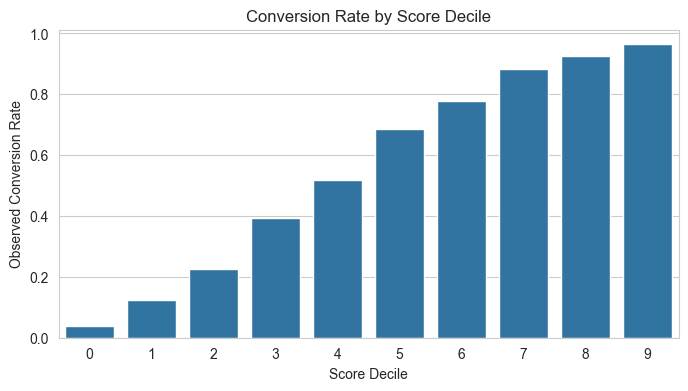

In [33]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=lift_table,
    x="score_decile",
    y="conversion_rate"
)

plt.title("Conversion Rate by Score Decile")
plt.xlabel("Score Decile")
plt.ylabel("Observed Conversion Rate")

plt.show()

In [34]:
overall_conversion = y_test.mean()

top_decile_conversion = (
    lift_table
    .sort_values("score_decile", ascending=False)
    .iloc[0]["conversion_rate"]
)

lift_top_decile = top_decile_conversion / overall_conversion

print(f"Conversão média geral: {overall_conversion:.2%}")
print(f"Conversão no decil superior: {top_decile_conversion:.2%}")
print(f"Lift no decil superior: {lift_top_decile:.2f}x")

Conversão média geral: 55.37%
Conversão no decil superior: 96.39%
Lift no decil superior: 1.74x


## Mensuração de impacto

In [35]:
impact_df = X_test.copy()

impact_df["offer_completed"] = y_test.values
impact_df["conversion_probability"] = final_y_proba

In [36]:
total_offers = len(impact_df)
budgets = [0.1, 0.2, 0.3, 0.5]
n_random_runs = 30

impact_results = []

for budget in budgets:
    n_offers = int(total_offers * budget)

    model_strategy = (
        impact_df
        .sort_values("conversion_probability", ascending=False)
        .head(n_offers)
    )

    random_conversion_rates = []
    random_conversions = []

    for seed in range(n_random_runs):
        random_strategy = impact_df.sample(
            n=n_offers,
            random_state=seed
        )
        random_conversion_rates.append(random_strategy["offer_completed"].mean())
        random_conversions.append(random_strategy["offer_completed"].sum())

    random_conversion_rate = np.mean(random_conversion_rates)
    random_conversions_mean = np.mean(random_conversions)

    impact_results.append({
        "budget_pct": budget,
        "n_offers": n_offers,
        "model_conversions": model_strategy["offer_completed"].sum(),
        "random_conversions_mean": random_conversions_mean,
        "model_conversion_rate": model_strategy["offer_completed"].mean(),
        "random_conversion_rate": random_conversion_rate,
        "incremental_conversions": (
            model_strategy["offer_completed"].sum()
            - random_conversions_mean
        ),
        "lift": (
            model_strategy["offer_completed"].mean()
            / random_conversion_rate
        )
    })

impact_results = pd.DataFrame(impact_results)
impact_results

,budget_pct,n_offers,model_conversions,random_conversions_mean,model_conversion_rate,random_conversion_rate,incremental_conversions,lift
0,0.1,1219,1175,679.666667,0.963905,0.557561,495.333333,1.728789
1,0.2,2438,2302,1349.900000,0.944217,0.553692,952.100000,1.705312
2,0.3,3657,3378,2026.300000,0.923708,0.554088,1351.700000,1.667078
3,0.5,6096,5164,3379.600000,0.847113,0.554396,1784.400000,1.527991


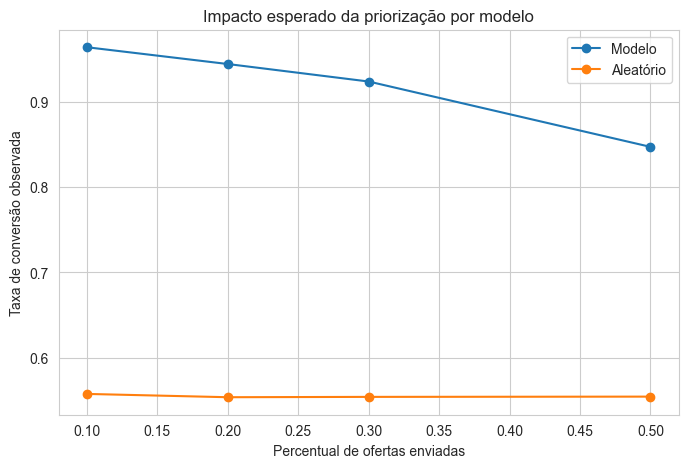

<Figure size 640x480 with 0 Axes>

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    impact_results["budget_pct"],
    impact_results["model_conversion_rate"],
    marker="o",
    label="Modelo"
)

plt.plot(
    impact_results["budget_pct"],
    impact_results["random_conversion_rate"],
    marker="o",
    label="Aleatório"
)

plt.title("Impacto esperado da priorização por modelo")
plt.xlabel("Percentual de ofertas enviadas")
plt.ylabel("Taxa de conversão observada")
plt.legend()

plt.show()

plt.savefig(
    "../images/campaign_simulation_lift.png",
    dpi=300,
    bbox_inches="tight"
)

A simulação comparou uma estratégia aleatória de envio de ofertas com uma estratégia baseada no score previsto pelo modelo.

Os resultados mostraram ganhos consistentes em todos os cenários avaliados.

No cenário mais restritivo, enviando ofertas para apenas 10% dos clientes com maior score previsto:

- estratégia aleatória: 54.3% de conversão;
- estratégia baseada no modelo: 96.4% de conversão;
- lift estimado: 1.77x.

Mesmo aumentando o volume de ofertas enviadas, o modelo manteve performance significativamente superior ao baseline aleatório.

Os resultados indicam forte capacidade do modelo em priorizar clientes com maior propensão de conversão, possibilitando:

- aumento de eficiência promocional;
- redução de desperdício de campanhas;
- melhor utilização do orçamento de marketing;
- maior retorno esperado das ações promocionais.

## Interpretação de negócio

A priorização por score permite selecionar ofertas com maior probabilidade prevista de conclusão.

Em um cenário de limitação de orçamento promocional ou volume máximo de campanhas, o modelo pode apoiar:

- priorização de clientes com maior propensão;
- escolha entre ofertas promocionais;
- redução de envios pouco eficientes;
- aumento esperado da taxa de conversão.

## Limitações

- A base possui inconsistências temporais no evento `offer viewed`.
- A modelagem usa `offer_completed` como proxy de sucesso promocional.
- Ofertas informacionais foram removidas da modelagem principal por não terem mecanismo equivalente de conclusão.
- A simulação de impacto é offline e não substitui um teste A/B ou avaliação causal.

## Próximos passos

- Avaliar tuning adicional dos modelos com validação cruzada por cliente.
- Expandir a estratégia de recomendação cliente-oferta simulando todas as ofertas elegíveis.
- Avaliar uplift modeling para medir impacto incremental real.
- Monitorar drift comportamental e recalibrar o modelo periodicamente.
- Incorporar regras de negócio para diversidade promocional, orçamento e frequência de comunicação.

## Simulação de recomendação Cliente X Oferta

Total simulated recommendations:
135952


/Users/dieb/Documents/case_ifood/offer-recommendation/venv_pyspark/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Best offer per customer:


,account_id,offer_id,offer_type,discount_value,min_value,duration,conversion_probability
1,0009655768c64bdeb2e877511632db8f,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3.0,7.0,7.0,0.968851
12,00116118485d4dfda04fdbaba9a87b5c,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5.0,5.0,7.0,0.055816
23,0011e0d4e6b944f998e987f904e8c1e5,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,0.949300
31,0020c2b971eb4e9188eac86d93036a77,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,0.989367
39,0020ccbbb6d84e358d3414a3ff76cffd,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,0.971360



Top 3 offers per customer:


,account_id,offer_id,offer_type,discount_value,min_value,duration,conversion_probability
1,0009655768c64bdeb2e877511632db8f,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3.0,7.0,7.0,0.968851
7,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,0.963077
6,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,0.928562
12,00116118485d4dfda04fdbaba9a87b5c,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5.0,5.0,7.0,0.055816
9,00116118485d4dfda04fdbaba9a87b5c,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3.0,7.0,7.0,0.050036
15,00116118485d4dfda04fdbaba9a87b5c,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,0.047688
23,0011e0d4e6b944f998e987f904e8c1e5,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,0.949300
17,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3.0,7.0,7.0,0.923994
20,0011e0d4e6b944f998e987f904e8c1e5,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5.0,5.0,7.0,0.900885
31,0020c2b971eb4e9188eac86d93036a77,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,0.989367


,offer_type,pct_recommended
0,discount,95.969166
1,bogo,4.030834


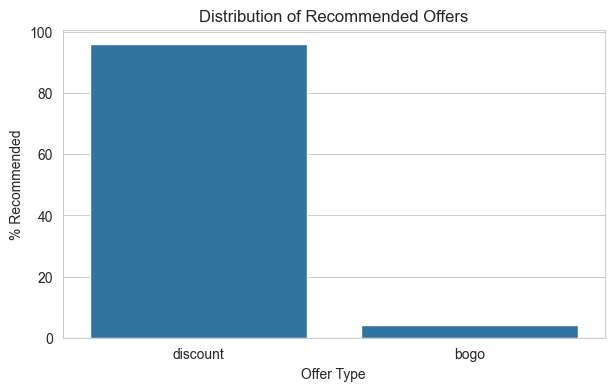

,offer_type,avg_score,max_score
1,discount,0.588534,0.998002
0,bogo,0.536048,0.991163


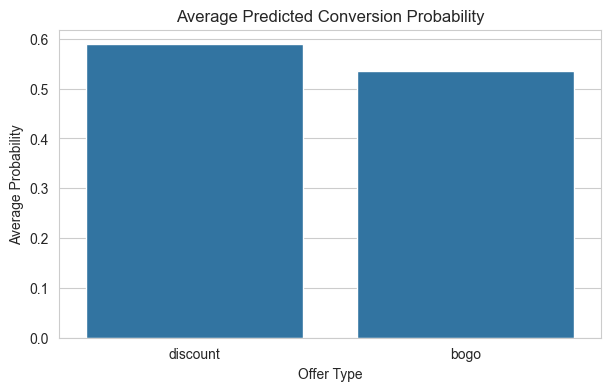

In [38]:
# ============================================================
# SIMULAÇÃO DE RECOMENDAÇÃO CLIENTE × OFERTA
# NEXT BEST OFFER
# ============================================================

# 1. Estado mais recente conhecido de cada cliente
customer_state_window = (
    Window
    .partitionBy("account_id")
    .orderBy(col("offer_received_time").desc())
)

customers_features = (
    customer_offer_final
    .withColumn("rn", row_number().over(customer_state_window))
    .filter(col("rn") == 1)
    .select(
        "account_id",
        "age",
        "gender",
        "credit_card_limit",
        "account_age_days",
        "transactions_before_offer",
        "amount_before_offer",
        "offers_received_before",
        "offers_completed_before",
        "bogo_offers_completed_before",
        "discount_offers_completed_before",
        "avg_ticket_before_offer",
        "completion_rate_before",
        "previous_offer_time_to_complete"
    )
)

# 2. Catálogo de ofertas promocionais elegíveis
offers_features = (
    customer_offer_final
    .select(
        "offer_id",
        "discount_value",
        "min_value",
        "duration",
        "offer_type",
        "email",
        "mobile",
        "social",
        "web"
    )
    .filter(col("offer_type").isin(["bogo", "discount"]))
    .dropDuplicates(["offer_id"])
)

# 3. Simulação cliente × todas as ofertas
recommendation_base = customers_features.crossJoin(offers_features)

print("Total simulated recommendations:")
print(recommendation_base.count())

recommendation_pdf = recommendation_base.toPandas()
recommendation_ids = recommendation_pdf[["account_id", "offer_id"]].copy()

# 4. Criar a mesma flag usada no treino
recommendation_pdf["credit_card_limit_missing"] = (
    recommendation_pdf["credit_card_limit"].isna().astype(int)
)

# 5. Garantir mesmas colunas e mesma ordem do treino
recommendation_X = recommendation_pdf[X_train.columns]

# 6. Predição de probabilidade
recommendation_pdf["conversion_probability"] = (
    final_model.predict_proba(recommendation_X)[:, 1]
)

# 7. Dataset final de recomendação
recommendation_output = pd.concat(
    [
        recommendation_ids,
        recommendation_pdf[
            [
                "offer_type",
                "discount_value",
                "min_value",
                "duration",
                "conversion_probability"
            ]
        ]
    ],
    axis=1
)

# 8. Melhor oferta por cliente
best_offer_per_customer = (
    recommendation_output
    .sort_values(
        ["account_id", "conversion_probability"],
        ascending=[True, False]
    )
    .groupby("account_id")
    .head(1)
)

# 9. Top 3 ofertas por cliente
top_3_offers_per_customer = (
    recommendation_output
    .sort_values(
        ["account_id", "conversion_probability"],
        ascending=[True, False]
    )
    .groupby("account_id")
    .head(3)
)

print("\nBest offer per customer:")
display(best_offer_per_customer.head())

print("\nTop 3 offers per customer:")
display(top_3_offers_per_customer.head(10))

# 10. Distribuição das ofertas recomendadas
recommended_offer_distribution = (
    best_offer_per_customer["offer_type"]
    .value_counts(normalize=True)
    .reset_index()
)

recommended_offer_distribution.columns = [
    "offer_type",
    "pct_recommended"
]

recommended_offer_distribution["pct_recommended"] *= 100

display(recommended_offer_distribution)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=recommended_offer_distribution,
    x="offer_type",
    y="pct_recommended"
)

plt.title("Distribution of Recommended Offers")
plt.xlabel("Offer Type")
plt.ylabel("% Recommended")

plt.show()

# 11. Score médio por tipo de oferta
offer_scores = (
    recommendation_output
    .groupby("offer_type")
    .agg(
        avg_score=("conversion_probability", "mean"),
        max_score=("conversion_probability", "max")
    )
    .reset_index()
    .sort_values("avg_score", ascending=False)
)

display(offer_scores)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=offer_scores,
    x="offer_type",
    y="avg_score"
)

plt.title("Average Predicted Conversion Probability")
plt.xlabel("Offer Type")
plt.ylabel("Average Probability")

plt.show()

In [39]:
customer_offer_final.groupby(
    "offer_type"
).agg(
    avg("offer_completed")
).show()

+-------------+--------------------+
|   offer_type|avg(offer_completed)|
+-------------+--------------------+
|     discount|  0.5880889238123301|
|informational|                 0.0|
|         bogo|  0.5137545493294862|
+-------------+--------------------+



In [40]:
customer_offer_final.groupby(
    "offer_type"
).count().show()

+-------------+-----+
|   offer_type|count|
+-------------+-----+
|     discount|30543|
|informational|15235|
|         bogo|30499|
+-------------+-----+



A simulação de recomendação mostrou predominância de ofertas do tipo discount entre as recomendações finais do modelo.

Esse comportamento sugere que, considerando os padrões históricos observados, ofertas discount apresentaram maior probabilidade prevista de conversão para grande parte dos clientes.

O resultado pode refletir:
- maior efetividade histórica desse tipo de campanha;
- diferenças estruturais entre mecânicas promocionais;
- ou padrões de targeting presentes nos dados observacionais.

Em um cenário real de produção, regras adicionais de negócio poderiam ser incorporadas ao sistema de recomendação para balancear diversidade promocional, orçamento e objetivos estratégicos.